## 🧭 LKH-3

**Concepts:** [LKH-3](../routers.md#lkh-3) · [Meta-heuristics](../routers.md#meta-heuristics)

The meta-heuristic used is K. Helsgaun's [LKH-3](http://akira.ruc.dk/~keld/research/LKH-3/), an extension to [LKH-2](http://akira.ruc.dk/~keld/research/LKH/) — see [LKH-3](../routers.md#lkh-3) for what it does and how it is distributed.

- K. Helsgaun, [An Extension of the Lin-Kernighan-Helsgaun TSP Solver for Constrained Traveling Salesman and Vehicle Routing Problems](http://akira.ruc.dk/~keld/research/LKH-3/LKH-3_REPORT.pdf). Technical Report, Roskilde University, 2017.

Note: _OptiWindNet_ interfaces with LKH through temporary files and system calls to the `LKH` executable, which must be in the **PATH** environment variable as seen from the Python code.

LKH-3 can produce both **radial**(default Open-CVRP) and **ringed**(`ringed=True` CVRP) topologies. Solutions can be used directly or as warm-starts for MILP models — see [Warm-starting](../routers.md#warm-starting).

If a routeset is desired, use _PathFinder_.

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.svg import svgplot
from optiwindnet.baselines.lkh import lkh3
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.interarraylib import G_from_S, as_normalized

### Load Greater Gabbard Inner

In [2]:
locations = load_repository()

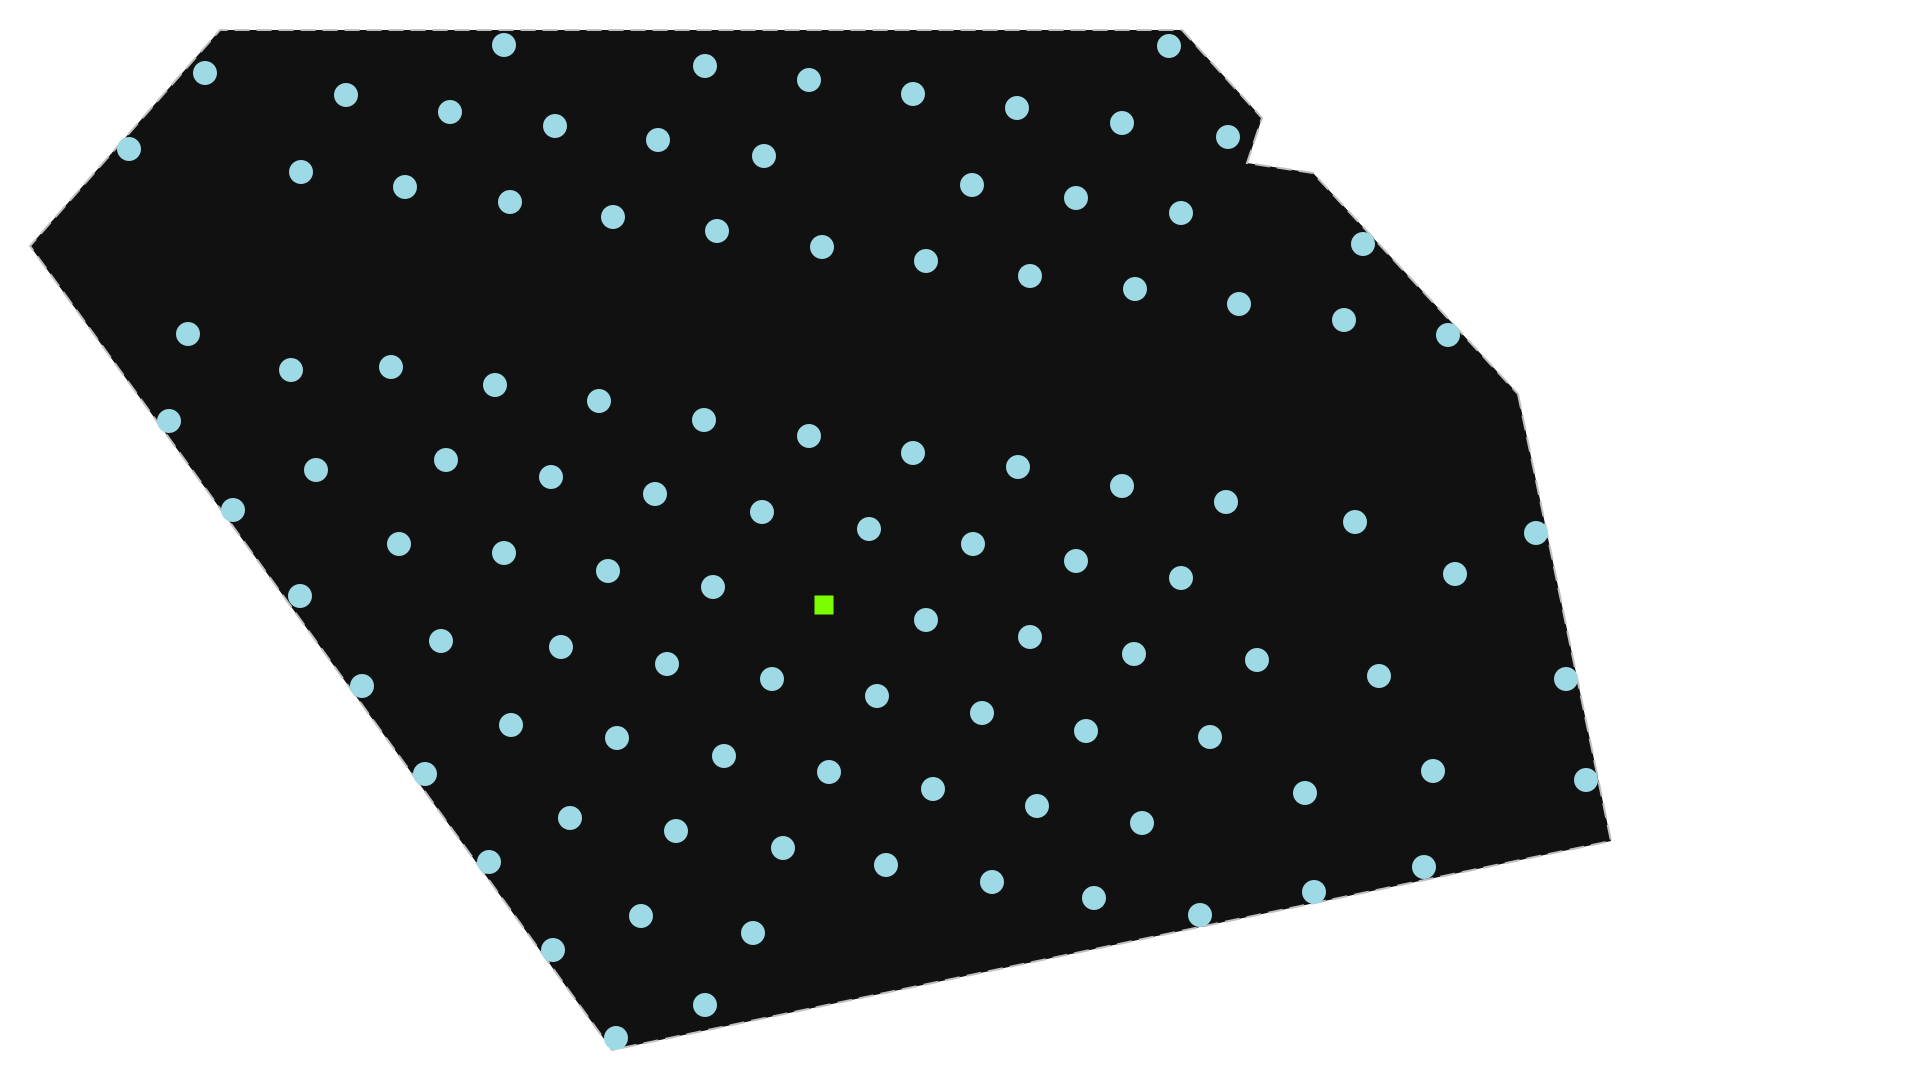

In [3]:
L = locations.gabbin
svgplot(L)

### Optimize Greater Gabbard Inner

0.79


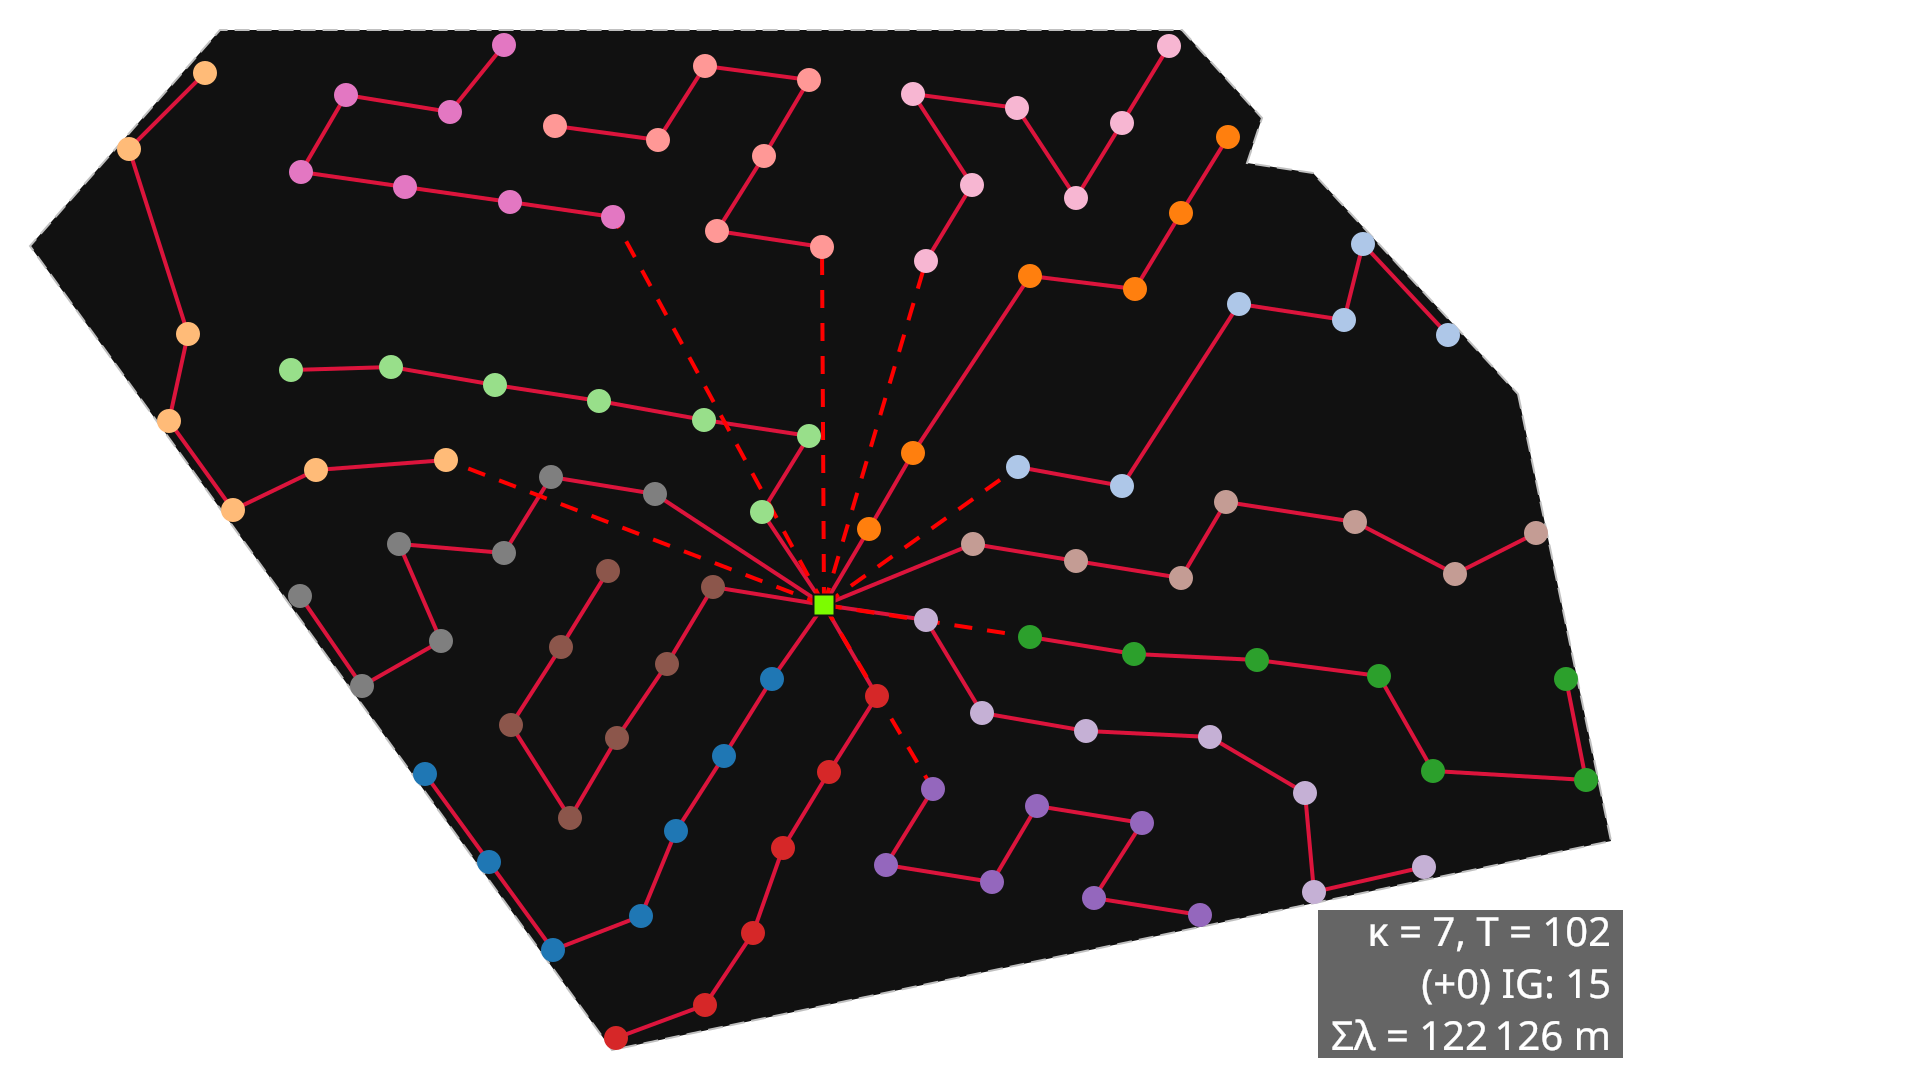

In [4]:
P, A = make_planar_embedding(L)
S = lkh3(as_normalized(A), capacity=7, time_limit=2)
print(S.graph['solution_time'])
G = G_from_S(S, A)
svgplot(G)

### Route the feeders so as to avoid crossings

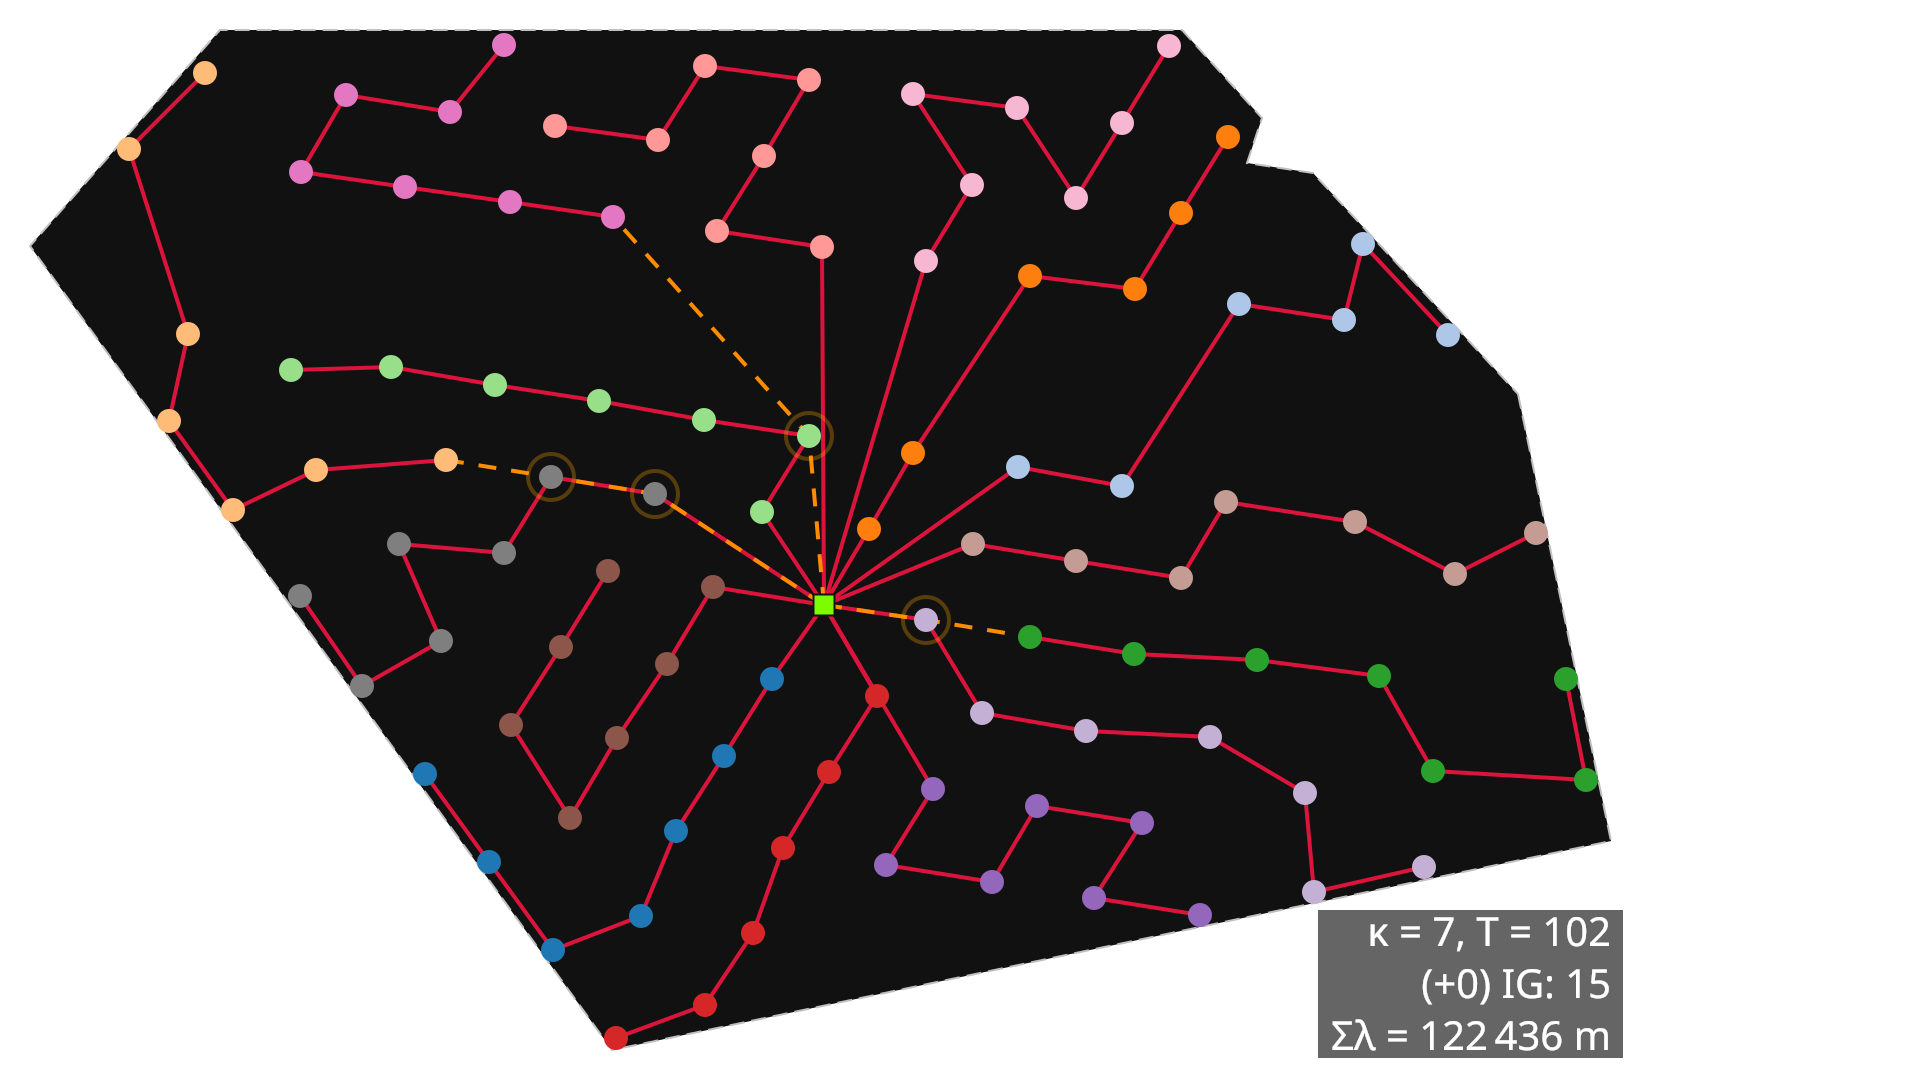

In [5]:
H = PathFinder(G, P, A).create_detours()
svgplot(H)

### Current LKH options

`warmstart` supplies initial tours derived from a feasible topology. `complete=True` fills missing candidate links with direct Euclidean links; leave it false to restrict the solve to the allowed graph. `runs` and `per_run_limit` are passed to LKH-3, and `seed` controls its pseudo-random seed. The wrapper repairs crossings iteratively by default; as with HGS, that repair work can make wall time exceed the per-run limit.

LKH returns an electrical topology. Convert it with [G_from_S()](../autoapi/optiwindnet/interarraylib/index.rst#optiwindnet.interarraylib.G_from_S) and route it with [PathFinder](../autoapi/optiwindnet/pathfinding/index.rst#optiwindnet.pathfinding.PathFinder) when a physical routeset is needed.